# [Контест](https://www.kaggle.com/competitions/classification-of-butterflies) на Kaggle

Необходимо решить задачу классификации изображений, на которых представлено 50 различных видов бабочек.

In [ ]:
%pip install opendatasets
import opendatasets as od
od.download_kaggle_dataset("https://www.kaggle.com/competitions/classification-of-butterflies/data", "")

In [ ]:
import os
from tqdm import tqdm

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms

import timm

from sklearn.metrics import confusion_matrix, classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Подготовка данных

In [ ]:
BATCH_SIZE = 32

In [ ]:
DATA_DIR = 'classification-of-butterflies'
TRAIN_DIR = os.path.join(DATA_DIR, 'train_butterflies', 'train_split')
TEST_DIR = os.path.join(DATA_DIR, 'test_butterflies', 'valid')

In [ ]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

TEST_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
FULL_DATASET = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=TRAIN_TRANSFORM
)

TRAIN_SIZE = int(0.8 * len(FULL_DATASET))
VAL_SIZE = len(FULL_DATASET) - TRAIN_SIZE
TRAIN_DATASET, VAL_DATASET = random_split(
    FULL_DATASET, [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator()
)
VAL_DATASET.dataset.transform = TEST_TRANSFORM

In [ ]:
FULL_LOADER = DataLoader(
    FULL_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

TRAIN_LOADER = DataLoader(
    TRAIN_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

VAL_LOADER = DataLoader(
    VAL_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

CLASS_TO_IDX = FULL_DATASET.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
print(f"Найдено классов: {len(CLASS_TO_IDX)}")
print(f"Размер обучающей выборки: {len(TRAIN_DATASET)}")
print(f"Размер валидационной выборки: {len(VAL_DATASET)}")

Найдено классов: 50
Размер обучающей выборки: 3964
Размер валидационной выборки: 991


# Тренировка и валидация

In [ ]:
model = timm.create_model('efficientnet_b0', pretrained=True)

NUM_FEATURES = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(NUM_FEATURES, 100),
    nn.ReLU(),
    nn.Linear(100, len(CLASS_TO_IDX))
)

model = model.to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 10

In [ ]:
def train_epoch(loader):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'Loss': f'{running_loss/total:.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


In [ ]:
def validate(loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({'Loss': f'{running_loss/total:.4f}',
                              'Acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [ ]:
def train(mode):  # TRAIN+VAL or FULL
    history = {
        'train_loss': [],
        'train_acc': [],

        'val_loss': [],
        'val_acc': []
    }
    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        print(f"\nЭпоха {epoch+1}/{EPOCHS}")
        print("-" * 50)

        if mode == "TRAIN+VAL":
            train_loss, train_acc = train_epoch(TRAIN_LOADER)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)

            val_loss, val_acc = validate(VAL_LOADER)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
        else:
            train_loss, train_acc = train_epoch(FULL_LOADER)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)

            val_loss, val_acc = 0.0, 0.0
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(f"\nРезультаты эпохи {epoch+1}:")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"Learning Rate: {current_lr:.6f}")

        if mode == "TRAIN+VAL":
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), 'best_model.pth')
                print(f"✓ Сохранена лучшая модель с точностью {val_acc:.2f}%")
        else:
            if train_acc > best_val_acc:
                best_val_acc = train_acc
                torch.save(model.state_dict(), 'best_model.pth')
                print(f"✓ Сохранена лучшая модель с точностью {train_acc:.2f}%")

    print(f"\nЛучшая точность на валидации: {best_val_acc:.2f}%")

    return history

In [ ]:
#history = train("TRAIN+VAL")
history = train("FULL")


Эпоха 1/10
--------------------------------------------------


Training: 100%|██████████| 155/155 [00:30<00:00,  5.02it/s, Loss=1.1309, Acc=71.38%]



Результаты эпохи 1:
Train Loss: 1.1309, Train Acc: 71.38%
Val Loss: 0.0000, Val Acc: 0.00%
Learning Rate: 0.001000
✓ Сохранена лучшая модель с точностью 71.38%

Эпоха 2/10
--------------------------------------------------


Training: 100%|██████████| 155/155 [00:25<00:00,  6.11it/s, Loss=0.3021, Acc=91.46%]



Результаты эпохи 2:
Train Loss: 0.3021, Train Acc: 91.46%
Val Loss: 0.0000, Val Acc: 0.00%
Learning Rate: 0.001000
✓ Сохранена лучшая модель с точностью 91.46%

Эпоха 3/10
--------------------------------------------------


...


Результаты эпохи 8:
Train Loss: 0.0095, Train Acc: 99.82%
Val Loss: 0.0000, Val Acc: 0.00%
Learning Rate: 0.000250
✓ Сохранена лучшая модель с точностью 99.82%

Эпоха 9/10
--------------------------------------------------


Training: 100%|██████████| 155/155 [00:27<00:00,  5.59it/s, Loss=0.0047, Acc=99.90%]



Результаты эпохи 9:
Train Loss: 0.0047, Train Acc: 99.90%
Val Loss: 0.0000, Val Acc: 0.00%
Learning Rate: 0.000125
✓ Сохранена лучшая модель с точностью 99.90%

Эпоха 10/10
--------------------------------------------------


Training: 100%|██████████| 155/155 [00:28<00:00,  5.51it/s, Loss=0.0040, Acc=99.98%]


Результаты эпохи 10:
Train Loss: 0.0040, Train Acc: 99.98%
Val Loss: 0.0000, Val Acc: 0.00%
Learning Rate: 0.000125
✓ Сохранена лучшая модель с точностью 99.98%

Лучшая точность на валидации: 99.98%


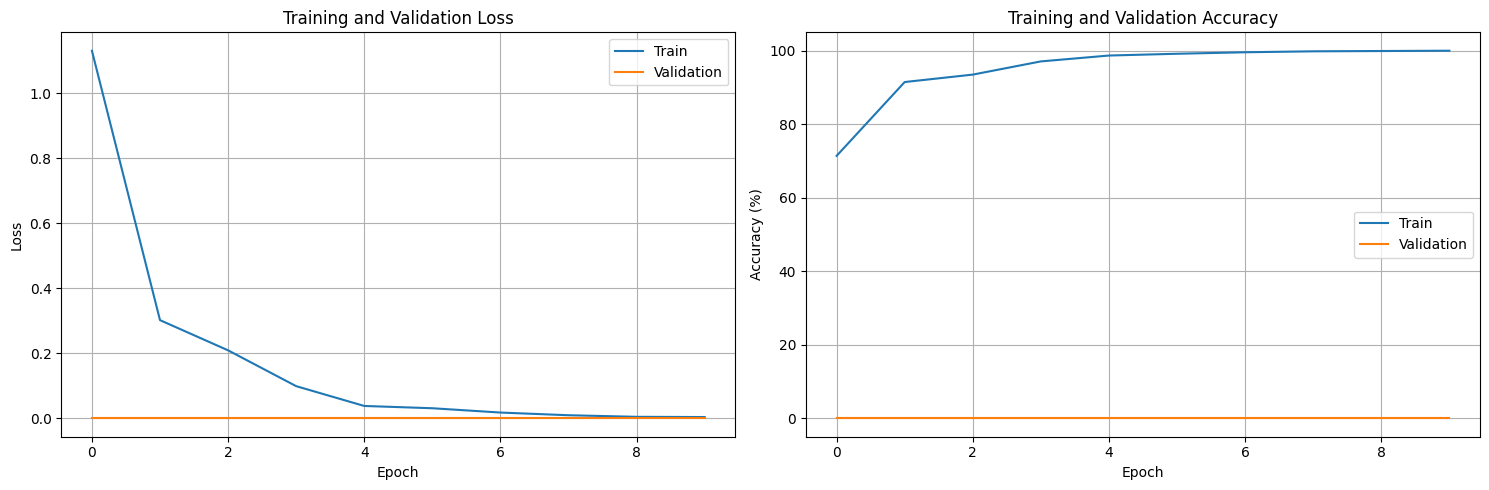

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

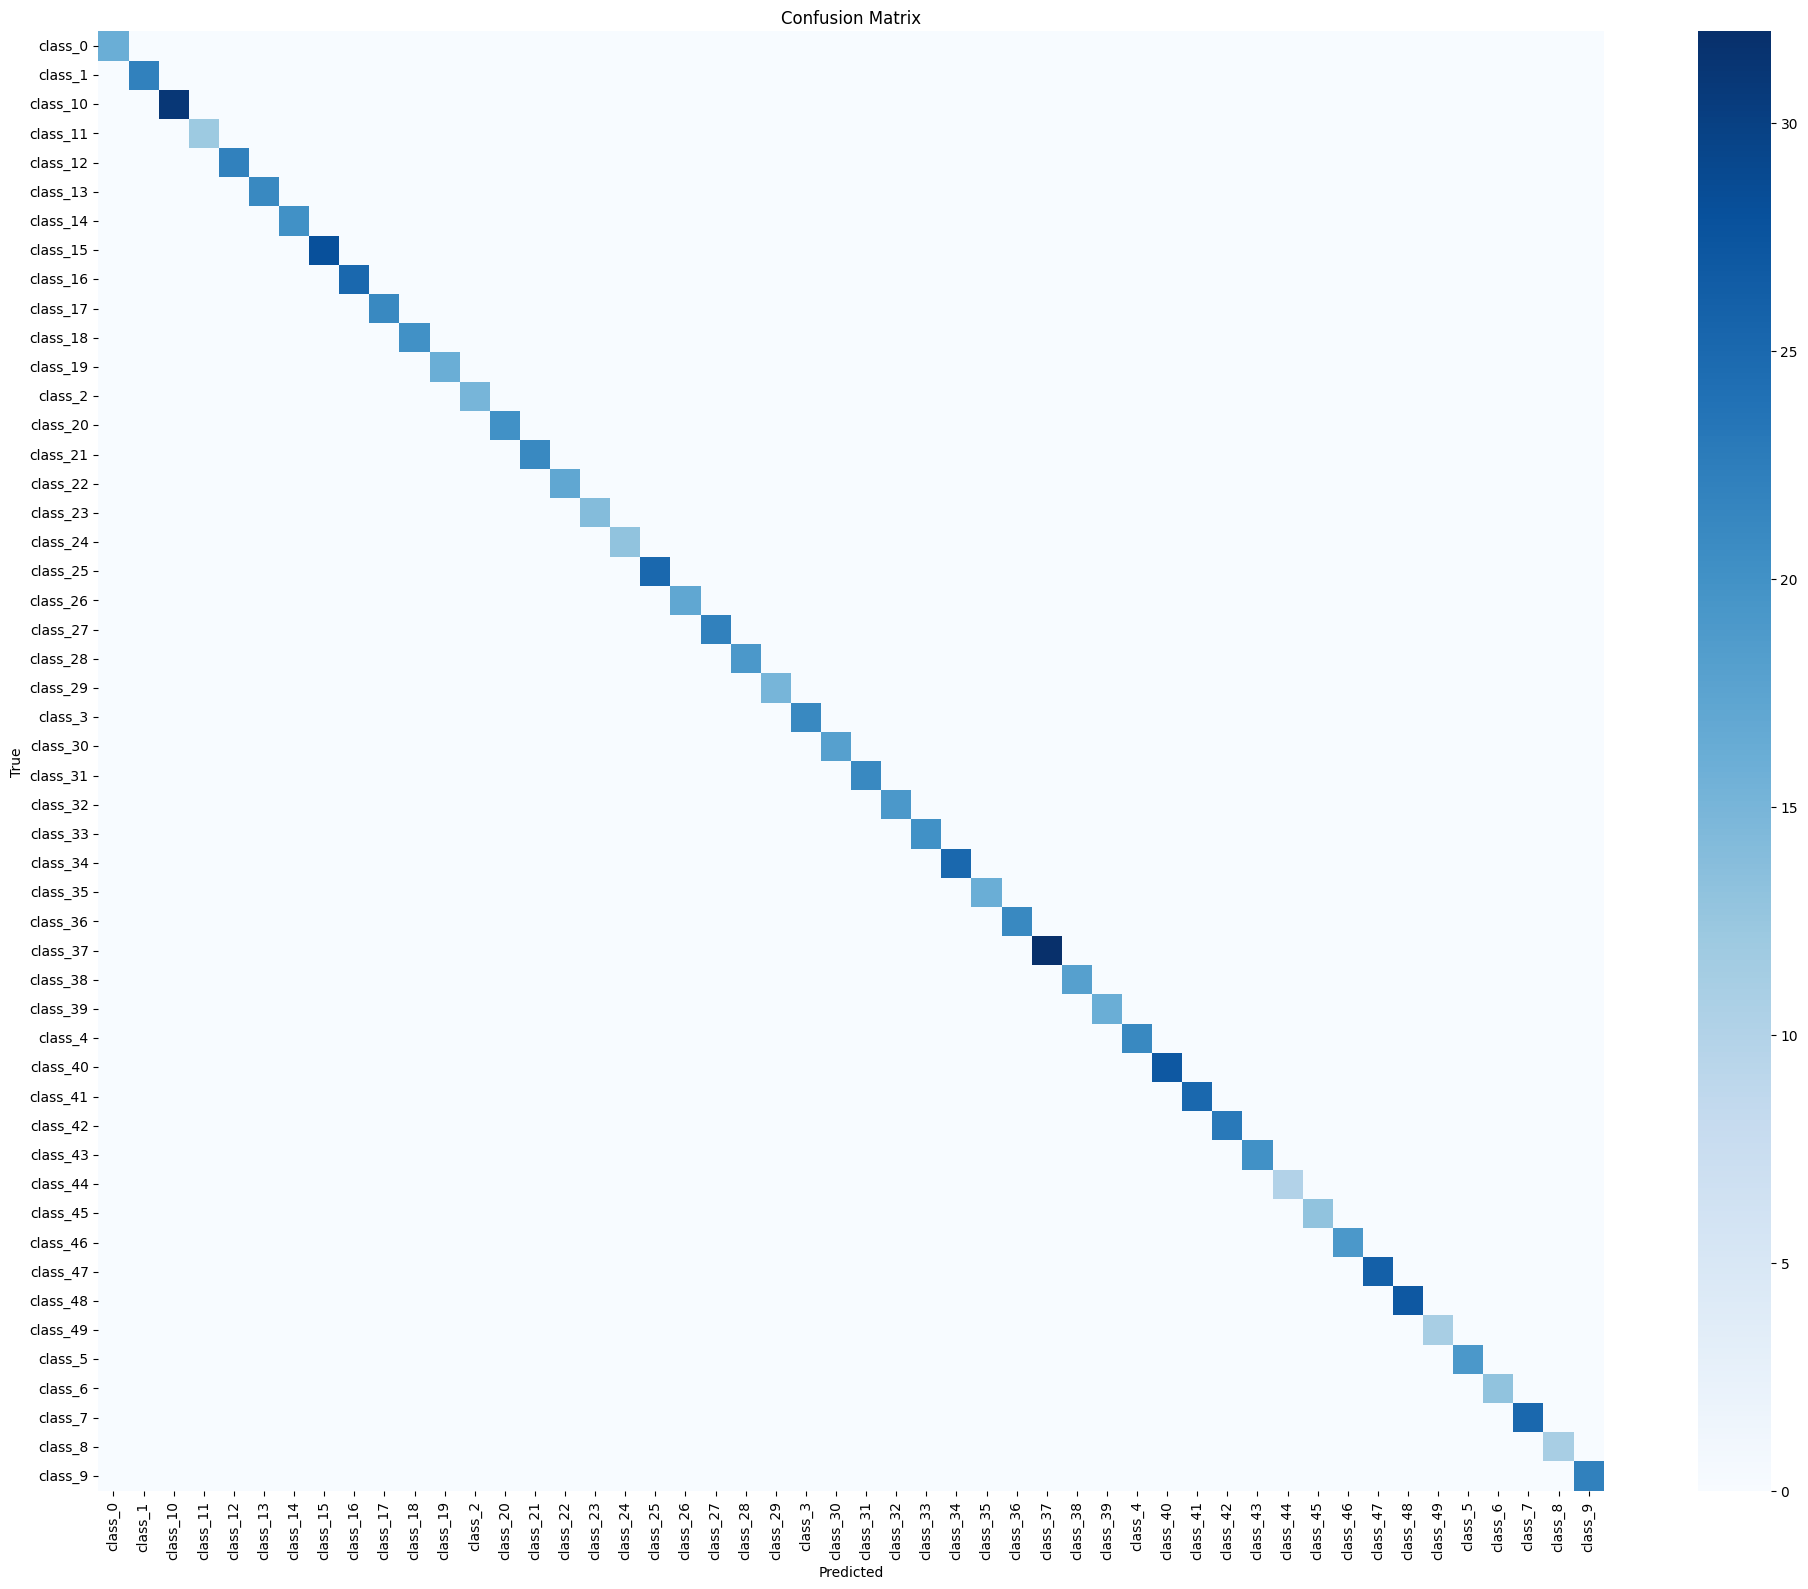


Отчет по классам:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        16
     class_1       1.00      1.00      1.00        22
    class_10       1.00      1.00      1.00        31
    class_11       1.00      1.00      1.00        12
    class_12       1.00      1.00      1.00        22
    class_13       1.00      1.00      1.00        21
    class_14       1.00      1.00      1.00        20
    class_15       1.00      1.00      1.00        28
    class_16       1.00      1.00      1.00        25
    class_17       1.00      1.00      1.00        21
    class_18       1.00      1.00      1.00        20
    class_19       1.00      1.00      1.00        16
     class_2       1.00      1.00      1.00        15
    class_20       1.00      1.00      1.00        20
    class_21       1.00      1.00      1.00        21
    class_22       1.00      1.00      1.00        17
    class_23       1.00      1.00      1.00        14
    clas

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in VAL_LOADER:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=list(IDX_TO_CLASS.values()),
            yticklabels=list(IDX_TO_CLASS.values()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print("\nОтчет по классам:")
print(classification_report(
    all_labels, all_preds,
    target_names=list(IDX_TO_CLASS.values()))
)

# Предсказания для контеста

In [ ]:
model.eval()

test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.jpg')],
                    key=lambda x: int(x.split('.')[0]))

predictions = []

print("Получение предсказаний...")
from PIL import Image
for fname in tqdm(test_files):
    img_path = os.path.join(TEST_DIR, fname)
    img = Image.open(img_path).convert('RGB')
    img_tensor = TEST_TRANSFORM(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)
        pred_idx = outputs.argmax(dim=1).item()

    folder_name = IDX_TO_CLASS[pred_idx]
    class_num = int(folder_name.replace('class_', ''))

    img_index = int(fname.split('.')[0])

    predictions.append({
        'index': img_index,
        'label': class_num
    })

results = pd.DataFrame(predictions)
results = results.sort_values(by='index')
results.to_csv('submission.csv', index=False)

print("Готово! Файл submission.csv сохранен.")
print(results.head())

Получение предсказаний...


100%|██████████| 250/250 [00:06<00:00, 41.62it/s]

Готово! Файл submission.csv сохранен.
   index  label
0      0     14
1      1     40
2      2      8
3      3     37
4      4     27
